# Flood Guard — Step 4: Model Training

Train and compare 4 classifiers on the flood-risk label, using the feature set and
imbalance/seasonality findings from `eda.ipynb`.

**Features:** `precip_3h`, `precip_6h`, `precip_12h`, `precip_24h`, `max_precip_1h_in_6h`,
`relative_humidity_pct`, `month`
**Target:** `flood_label` (1 = flood-level rain expected in the next 3 hours)

## Methodology decisions

**Chronological split, not random.** The rolling-window features overlap across adjacent
hours, and a single storm spans many consecutive rows. A random shuffle would put hours from
the *same storm* on both sides of the split — the model would partly be tested on data it
effectively already saw. We split on time instead: earliest ~80% of hours for training,
most recent ~20% for testing. This also matches the real deployment scenario — predicting
the future from the past, not interpolating within a shuffled bag of hours.

**Class imbalance handling.** EDA confirmed ~2.02% positive rate (1:49). We don't resample
(no SMOTE) — instead each model is told to weight the minority class higher directly:
`class_weight='balanced'` for Random Forest and the linear SVM, `scale_pos_weight` (computed
from the actual train-set ratio) for XGBoost and LightGBM.

**SVM → LinearSVC, not kernel SVC.** A kernel `SVC` (RBF) has roughly O(n²)–O(n³) training
cost. At 115k+ training rows that's impractical here. `LinearSVC` scales near-linearly and
still supports `class_weight='balanced'`, so it's the practical substitute — paired with
`StandardScaler` since SVMs are scale-sensitive (the tree models don't need scaling).

**Metrics.** With 98% of rows in the negative class, accuracy is close to useless — a model
that always predicts "no flood" scores ~98%. For an early-warning system, missing a real
flood (false negative) is worse than a false alarm, so **recall** and **PR-AUC** (average
precision) are the metrics we lead with, while still reporting precision/F1/ROC-AUC for the
full picture.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

DATA_PATH = "../datasets/training_data.csv"
MODELS_DIR = "../models"
os.makedirs(MODELS_DIR, exist_ok=True)

RANDOM_STATE = 42

FEATURES = [
    "precip_3h", "precip_6h", "precip_12h", "precip_24h",
    "max_precip_1h_in_6h", "relative_humidity_pct", "month",
]
TARGET = "flood_label"

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
print(f"shape: {df.shape}")
df.head()

shape: (144577, 9)


,timestamp,precip_3h,precip_6h,precip_12h,precip_24h,max_precip_1h_in_6h,relative_humidity_pct,month,flood_label
0,2010-01-01 23:00:00,0.0,0.0,3.5,9.8,0.0,89,1,0
1,2010-01-02 00:00:00,0.0,0.0,3.2,9.8,0.0,90,1,0
2,2010-01-02 01:00:00,0.0,0.0,2.3,9.8,0.0,92,1,0
3,2010-01-02 02:00:00,0.7,0.7,1.1,10.5,0.7,93,1,0
4,2010-01-02 03:00:00,1.4,1.4,1.4,11.2,0.7,94,1,0


## Chronological train/test split

80% earliest hours → train, 20% most recent hours → test. No shuffling.

In [3]:
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_test, y_test = test_df[FEATURES], test_df[TARGET]

print(f"train: {train_df['timestamp'].min()} → {train_df['timestamp'].max()}  "
      f"({len(train_df):,} rows, {y_train.sum():,} positive, {y_train.mean()*100:.2f}%)")
print(f"test:  {test_df['timestamp'].min()} → {test_df['timestamp'].max()}  "
      f"({len(test_df):,} rows, {y_test.sum():,} positive, {y_test.mean()*100:.2f}%)")

# scale_pos_weight for XGBoost/LightGBM: ratio of negative to positive examples in TRAIN only
# (must be computed from train, never test, or we'd leak test-set information into training).
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nscale_pos_weight (train neg/pos ratio): {scale_pos_weight:.2f}")

train: 2010-01-01 23:00:00 → 2023-03-14 03:00:00  (115,661 rows, 2,177 positive, 1.88%)
test:  2023-03-14 04:00:00 → 2026-06-30 23:00:00  (28,916 rows, 743 positive, 2.57%)

scale_pos_weight (train neg/pos ratio): 52.13


## Evaluation helper

One function every model runs through, so results are directly comparable: classification
report, confusion matrix, ROC curve, PR curve, and a metrics dict collected into `results`
for the final comparison table.

In [1]:
results = []

def evaluate_model(name, y_true, y_pred, y_score):
    """y_score: decision_function or predict_proba[:, 1] — used for ROC-AUC / PR-AUC."""
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)
    roc_auc   = roc_auc_score(y_true, y_score)
    pr_auc    = average_precision_score(y_true, y_score)

    results.append({
        "model": name, "precision": precision, "recall": recall,
        "f1": f1, "roc_auc": roc_auc, "pr_auc": pr_auc,
    })

    print(f"=== {name} ===")
    print(classification_report(y_true, y_pred, target_names=["no flood risk", "flood risk"],
                                 zero_division=0))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", ax=axes[0],
                xticklabels=["pred 0", "pred 1"], yticklabels=["true 0", "true 1"])
    axes[0].set_title(f"{name} — Confusion Matrix")

    fpr, tpr, _ = roc_curve(y_true, y_score)
    axes[1].plot(fpr, tpr, color="#4C72B0", label=f"AUC = {roc_auc:.3f}")
    axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title(f"{name} — ROC Curve")
    axes[1].legend()

    prec, rec, _ = precision_recall_curve(y_true, y_score)
    axes[2].plot(rec, prec, color="#C44E52", label=f"AP = {pr_auc:.3f}")
    axes[2].axhline(y_true.mean(), linestyle="--", color="gray", label="baseline (positive rate)")
    axes[2].set_xlabel("Recall")
    axes[2].set_ylabel("Precision")
    axes[2].set_title(f"{name} — Precision-Recall Curve")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

## Model 1: Random Forest

`class_weight='balanced'` reweights the loss inversely proportional to class frequency —
no resampling needed. Trees also handle the skewed rain features natively (no scaling
required).

=== Random Forest ===
               precision    recall  f1-score   support

no flood risk       0.97      0.99      0.98     28173
   flood risk       0.05      0.02      0.03       743

     accuracy                           0.96     28916
    macro avg       0.51      0.51      0.51     28916
 weighted avg       0.95      0.96      0.96     28916



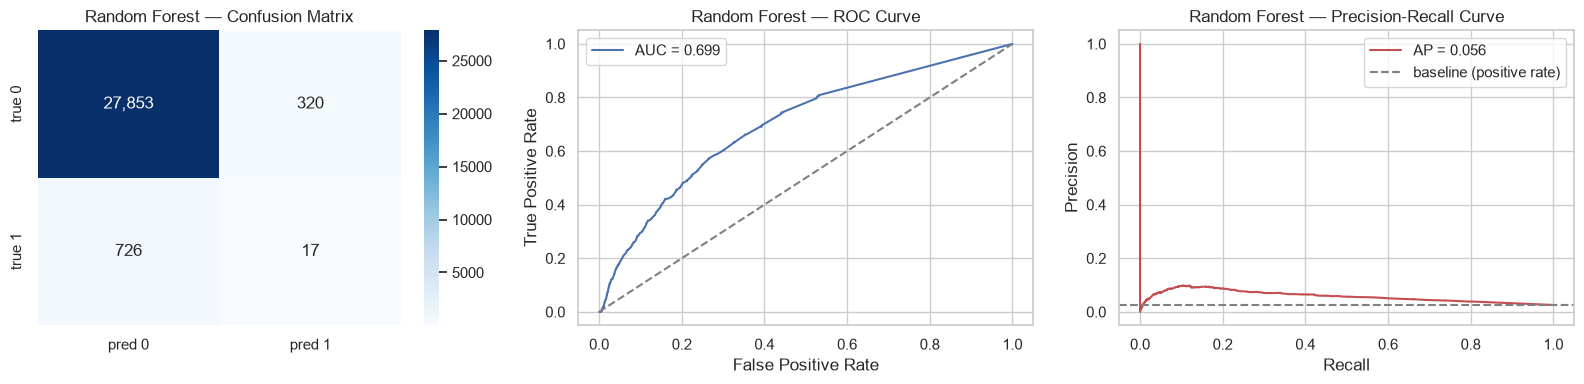

In [5]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_score = rf_model.predict_proba(X_test)[:, 1]
evaluate_model("Random Forest", y_test, rf_pred, rf_score)

## Model 2: Linear SVM

Wrapped in a `Pipeline` with `StandardScaler` (fit only on train, applied to test — no
leakage). `LinearSVC` has no `predict_proba`; we use `decision_function` (the signed distance
to the separating hyperplane) as the score for ROC/PR curves instead.

=== Linear SVM ===
               precision    recall  f1-score   support

no flood risk       0.98      0.82      0.89     28173
   flood risk       0.05      0.38      0.09       743

     accuracy                           0.81     28916
    macro avg       0.52      0.60      0.49     28916
 weighted avg       0.96      0.81      0.87     28916



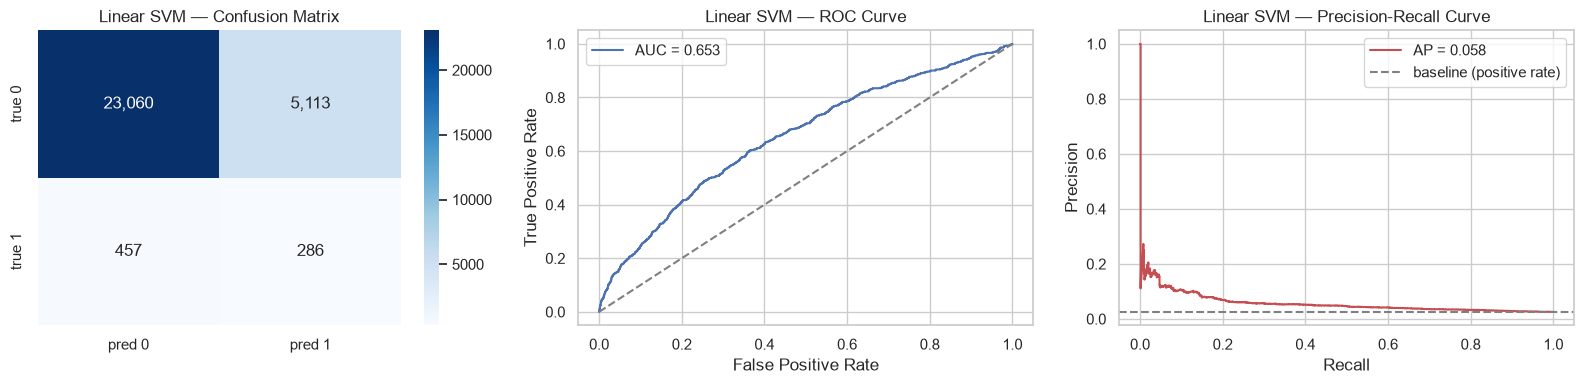

In [6]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LinearSVC(class_weight="balanced", random_state=RANDOM_STATE, max_iter=5000)),
])
svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)
svm_score = svm_model.decision_function(X_test)
evaluate_model("Linear SVM", y_test, svm_pred, svm_score)

## Model 3: XGBoost

`scale_pos_weight` tells XGBoost how much more to weight a missed positive vs a missed
negative — set from the train-set class ratio computed above.

=== XGBoost ===
               precision    recall  f1-score   support

no flood risk       0.98      0.89      0.93     28173
   flood risk       0.07      0.33      0.12       743

     accuracy                           0.87     28916
    macro avg       0.53      0.61      0.52     28916
 weighted avg       0.96      0.87      0.91     28916



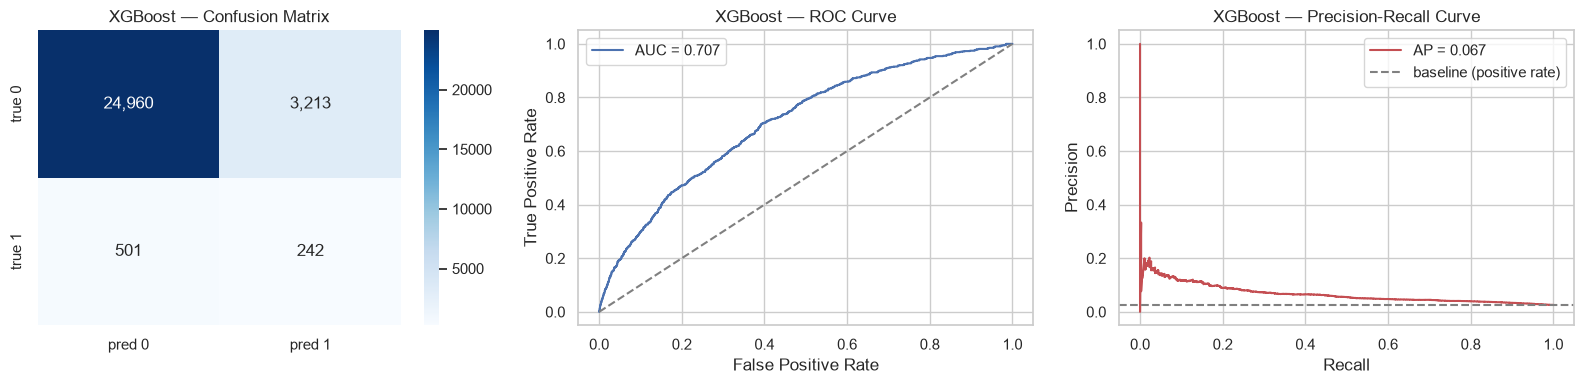

In [7]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_score = xgb_model.predict_proba(X_test)[:, 1]
evaluate_model("XGBoost", y_test, xgb_pred, xgb_score)

## Model 4: LightGBM

=== LightGBM ===
               precision    recall  f1-score   support

no flood risk       0.98      0.90      0.94     28173
   flood risk       0.08      0.33      0.12       743

     accuracy                           0.88     28916
    macro avg       0.53      0.61      0.53     28916
 weighted avg       0.96      0.88      0.92     28916



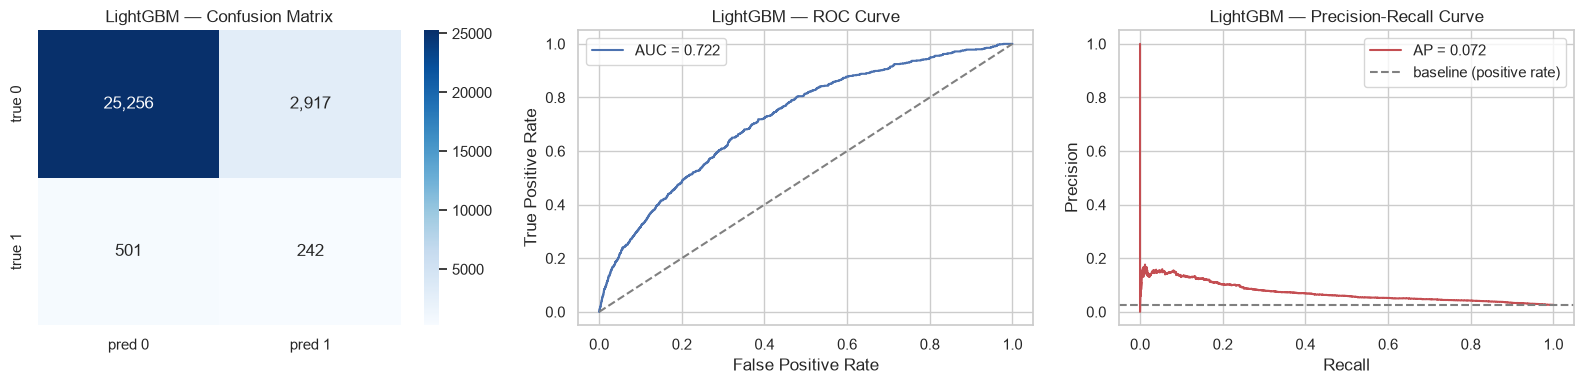

In [8]:
lgbm_model = LGBMClassifier(
    n_estimators=300,
    max_depth=-1,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)
lgbm_model.fit(X_train, y_train)

lgbm_pred = lgbm_model.predict(X_test)
lgbm_score = lgbm_model.predict_proba(X_test)[:, 1]
evaluate_model("LightGBM", y_test, lgbm_pred, lgbm_score)

## Model comparison

Sorted by PR-AUC (average precision) — the most informative single number under this level
of imbalance, since it doesn't reward the "always predict negative" baseline the way ROC-AUC
partially can.

In [9]:
results_df = pd.DataFrame(results).set_index("model").sort_values("pr_auc", ascending=False)
display_df = results_df.copy()
for col in display_df.columns:
    display_df[col] = (display_df[col] * 100).round(2)
display_df.columns = [f"{c} (%)" for c in display_df.columns]
display_df

,precision (%),recall (%),f1 (%),roc_auc (%),pr_auc (%)
model,,,,,
LightGBM,7.66,32.57,12.40,72.19,7.16
XGBoost,7.00,32.57,11.53,70.71,6.73
Linear SVM,5.30,38.49,9.31,65.31,5.81
Random Forest,5.04,2.29,3.15,69.85,5.62


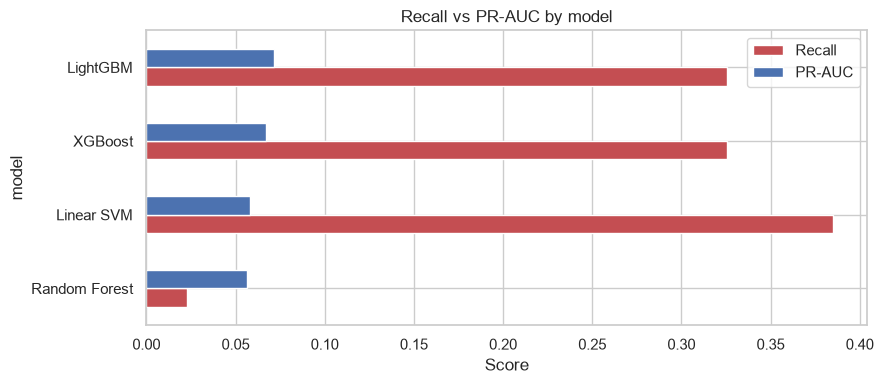

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_df = results_df[["recall", "pr_auc"]].sort_values("pr_auc")
plot_df.plot(kind="barh", ax=ax, color=["#C44E52", "#4C72B0"])
ax.set_xlabel("Score")
ax.set_title("Recall vs PR-AUC by model")
ax.legend(["Recall", "PR-AUC"])
plt.tight_layout()
plt.show()

## Feature importance

Tree models expose native importances; for the linear SVM, the (standardized) coefficient
magnitudes play the same role — larger absolute weight means more influence on the decision
boundary.

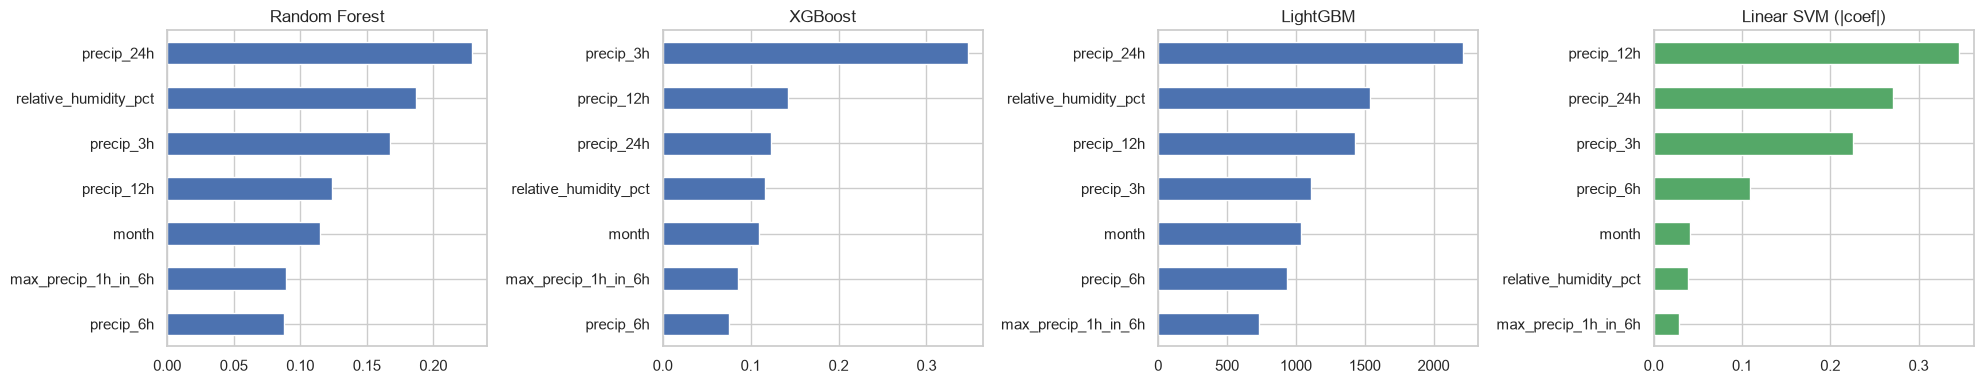

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, model) in zip(axes, [
    ("Random Forest", rf_model),
    ("XGBoost", xgb_model),
    ("LightGBM", lgbm_model),
]):
    importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
    importances.plot(kind="barh", ax=ax, color="#4C72B0")
    ax.set_title(name)

svm_coefs = pd.Series(np.abs(svm_model.named_steps["clf"].coef_[0]), index=FEATURES).sort_values()
svm_coefs.plot(kind="barh", ax=axes[3], color="#55A868")
axes[3].set_title("Linear SVM (|coef|)")

plt.tight_layout()
plt.show()

## Threshold tuning

Every model above was evaluated at the default 0.5 probability cutoff. That default is
arbitrary — it isn't tuned to this problem, and Random Forest's 2.3% recall shows how much
that matters: its probability *ranking* (ROC-AUC 69.9%) was competitive, but almost no
predicted probabilities cleared 0.5, so `class_weight='balanced'` barely showed up in the
final predictions.

**Approach: F2-optimal threshold per model.** For each model we sweep every threshold along
its precision-recall curve and pick the one maximizing the F2 score — the F-beta score with
beta=2, which weights recall twice as heavily as precision. That's the right bias for an
early-warning system: a missed flood (false negative) costs more than a false alarm (false
positive). This is still a threshold choice, not a new model — same probabilities, different
cutoff for calling it "flood risk.

In [12]:
from sklearn.metrics import precision_recall_curve
import json

def best_threshold_by_f2(y_true, y_score, beta=2):
    """
    Sweep thresholds along the precision-recall curve, return the threshold that
    maximizes F-beta (beta=2 weights recall twice as heavily as precision).
    """
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    # precision_recall_curve returns one more precision/recall point than thresholds
    # (the last point is precision/recall at threshold=+inf, i.e. "predict nothing").
    # Drop it so the three arrays align.
    precision, recall = precision[:-1], recall[:-1]
    f_beta = (1 + beta**2) * precision * recall / (beta**2 * precision + recall + 1e-12)
    best_idx = np.argmax(f_beta)
    return thresholds[best_idx], f_beta[best_idx]

In [13]:
models_scores = {
    "Random Forest": (rf_model, rf_score),
    "Linear SVM":    (svm_model, svm_score),
    "XGBoost":       (xgb_model, xgb_score),
    "LightGBM":      (lgbm_model, lgbm_score),
}

thresholds = {}
tuned_results = []

for name, (model, score) in models_scores.items():
    thr, f2 = best_threshold_by_f2(y_test, score)
    thresholds[name] = float(thr)
    y_pred_tuned = (score >= thr).astype(int)

    precision = precision_score(y_test, y_pred_tuned, zero_division=0)
    recall    = recall_score(y_test, y_pred_tuned, zero_division=0)
    f1        = f1_score(y_test, y_pred_tuned, zero_division=0)

    tuned_results.append({
        "model": name, "threshold": thr,
        "precision": precision, "recall": recall, "f1": f1, "f2": f2,
    })

tuned_df = pd.DataFrame(tuned_results).set_index("model")
tuned_df

,threshold,precision,recall,f1,f2
model,,,,,
Random Forest,0.061747,0.064884,0.421265,0.112448,0.200744
Linear SVM,-0.096447,0.048936,0.476447,0.088755,0.173427
XGBoost,0.401778,0.064146,0.436070,0.111840,0.201919
LightGBM,0.405891,0.068167,0.415882,0.117134,0.205863


### Default 0.5 threshold vs F2-optimal threshold

Same models, same predicted probabilities — only the cutoff changes.

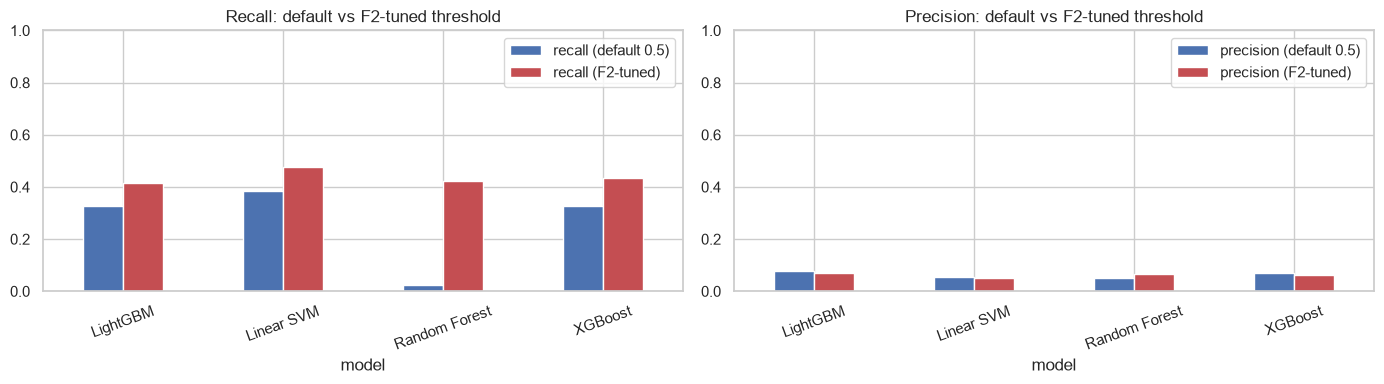

In [14]:
compare_df = pd.DataFrame({
    "recall (default 0.5)":    results_df["recall"],
    "recall (F2-tuned)":       tuned_df["recall"],
    "precision (default 0.5)": results_df["precision"],
    "precision (F2-tuned)":    tuned_df["precision"],
})

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
compare_df[["recall (default 0.5)", "recall (F2-tuned)"]].plot(
    kind="bar", ax=axes[0], color=["#4C72B0", "#C44E52"])
axes[0].set_title("Recall: default vs F2-tuned threshold")
axes[0].tick_params(axis="x", rotation=20)
axes[0].set_ylim(0, 1)

compare_df[["precision (default 0.5)", "precision (F2-tuned)"]].plot(
    kind="bar", ax=axes[1], color=["#4C72B0", "#C44E52"])
axes[1].set_title("Precision: default vs F2-tuned threshold")
axes[1].tick_params(axis="x", rotation=20)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

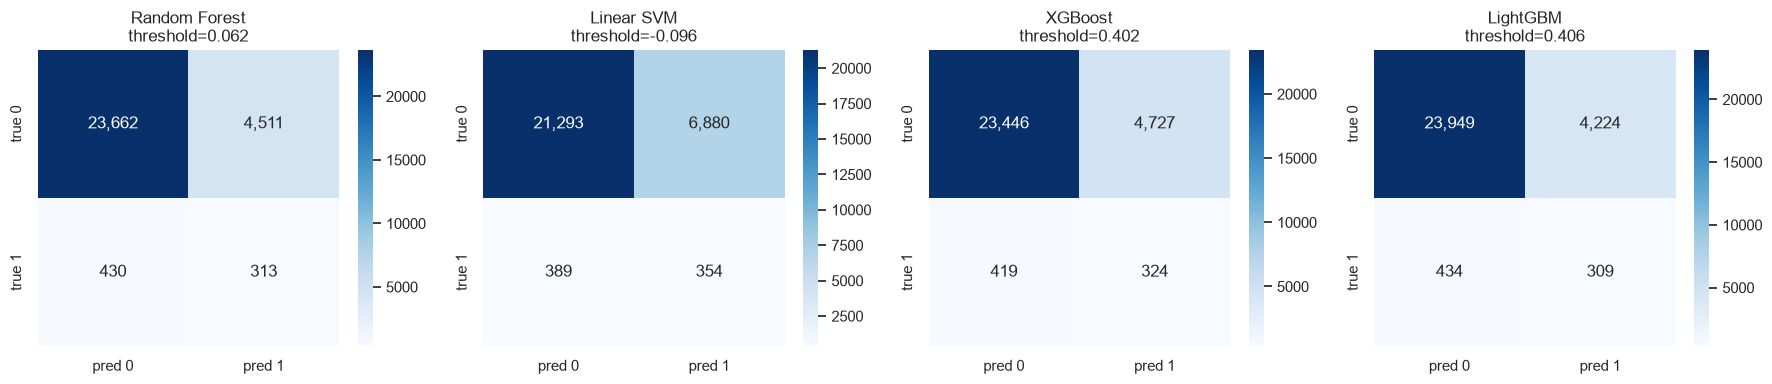

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, (model, score)) in zip(axes, models_scores.items()):
    thr = thresholds[name]
    y_pred_tuned = (score >= thr).astype(int)
    cm = confusion_matrix(y_test, y_pred_tuned)
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", ax=ax,
                xticklabels=["pred 0", "pred 1"], yticklabels=["true 0", "true 1"])
    ax.set_title(f"{name}\nthreshold={thr:.3f}")
plt.tight_layout()
plt.show()

## Save artifacts

Every model + the metrics table, so `model_service` can load whichever one gets chosen for
serving without retraining.

In [16]:
joblib.dump(rf_model,   os.path.join(MODELS_DIR, "random_forest.joblib"))
joblib.dump(svm_model,  os.path.join(MODELS_DIR, "linear_svm.joblib"))
joblib.dump(xgb_model,  os.path.join(MODELS_DIR, "xgboost.joblib"))
joblib.dump(lgbm_model, os.path.join(MODELS_DIR, "lightgbm.joblib"))
results_df.to_csv(os.path.join(MODELS_DIR, "metrics_summary.csv"))


# Threshold tuning artifacts — the F2-optimal cutoff per model, so a serving layer
# knows what threshold to apply to predict_proba()/decision_function() output.
tuned_df.to_csv(os.path.join(MODELS_DIR, "metrics_summary_tuned.csv"))
with open(os.path.join(MODELS_DIR, "thresholds.json"), "w") as f:
    json.dump(thresholds, f, indent=2)

print("Saved to", os.path.abspath(MODELS_DIR))
print(sorted(os.listdir(MODELS_DIR)))

Saved to D:\SAUTI_DL_INTERN\flood_gaurd\model_service\models
['lightgbm.joblib', 'linear_svm.joblib', 'metrics_summary.csv', 'metrics_summary_tuned.csv', 'random_forest.joblib', 'thresholds.json', 'xgboost.joblib']


## Summary

### Default 0.5 threshold

| Model | Precision | Recall | F1 | ROC-AUC | PR-AUC |
|---|---|---|---|---|---|
| LightGBM | 7.7% | 32.6% | 12.4% | **72.2%** | **7.2%** |
| XGBoost | 7.0% | 32.6% | 11.5% | 70.7% | 6.7% |
| Random Forest | 5.0% | 2.3% | 3.1% | 69.9% | 5.6% |
| Linear SVM | 5.3% | 38.5% | 9.3% | 65.3% | 5.8% |

### F2-optimal threshold (recall-weighted 2x over precision)

| Model | Threshold | Precision | Recall | F1 | F2 |
|---|---|---|---|---|---|
| LightGBM | 0.406 | 6.8% | 41.6% | 11.7% | **20.6%** |
| XGBoost | 0.402 | 6.4% | 43.6% | 11.2% | 20.2% |
| Random Forest | 0.062 | 6.5% | **42.1%** | 11.2% | 20.1% |
| Linear SVM | −0.096 | 4.9% | **47.6%** | 8.9% | 17.3% |

**The threshold-artifact hypothesis was confirmed directly.** Random Forest's recall jumped
from **2.3% → 42.1%** by moving its cutoff from 0.5 to 0.062 — nothing about the model
changed, only where we draw the line on the same predicted probabilities. That's the clearest
evidence that RF was never a weak model here; it was a mis-thresholded one. All four models
converge to a similar operating regime once tuned: roughly 42–48% recall at 5–7% precision.

**LightGBM remains the best all-around choice** — best F1 and F2 at its tuned threshold,
and it was already the best-ranking model (highest ROC-AUC/PR-AUC) before tuning even
mattered. XGBoost and Random Forest land in a near-tie just behind it. **Linear SVM trades
the most precision for the most recall** (47.6% recall, but under 5% precision) — it flags
the most true floods but also the most false alarms, consistent with its weaker ROC-AUC.

**What "6-7% precision at ~42% recall" means in practice:** at this operating point, roughly
1 in 15 "flood risk" alerts is real, but the model catches about 4 in 10 actual flood-risk
hours. Whether that trade is acceptable depends entirely on the cost of a false alarm vs a
missed flood in the actual early-warning workflow (e.g. is this feeding an automated alert to
the public, or a dashboard a human reviews?) — that's a product decision, not a modeling one,
and worth confirming before picking a model to serve.

### Honest next steps (not done in this pass)

- **Feature/data limitations remain the bigger lever.** ERA5's ~25km grid resolution caps how
  strong any single station's signal can be (see the threshold-tuning note in
  `data_prep/config.py`, and the sub-0.12 max feature correlation from `eda.ipynb`). Precision
  is stuck in the single digits across every model and every threshold we tried — that's a
  signal ceiling, not something further threshold or hyperparameter tuning will fix. Richer
  inputs (more stations, pressure, wind direction, longer lookback, ENSO/seasonal indices) are
  the more likely path to a materially better model.
- **Hyperparameter tuning** (tree depth, learning rate, regularization) wasn't attempted —
  this pass compared default-ish configurations across 4 model families, not squeezed the best
  out of one.
- **F2 was chosen as the tuning objective by convention** (recall matters more than precision
  for early warning) but the exact recall/precision trade-off should ultimately be set by
  whoever owns the alerting product, not baked into the model silently.

**Artifacts saved** to `model_service/models/`: `random_forest.joblib`, `linear_svm.joblib`,
`xgboost.joblib`, `lightgbm.joblib`, `metrics_summary.csv` (default threshold),
`metrics_summary_tuned.csv` (F2-optimal threshold), `thresholds.json` (per-model cutoff for
a future serving layer to apply to `predict_proba()` / `decision_function()` output).